# 14-Day Window: LightGBM vs XGBoost
This notebook trains two models (LGBM and XGB) on the `lgbm_14` dataset, compares MAE/SMAPE/BIAS/RMSE, and visualizes predictions and residuals.

## 1) Imports and Paths
This cell imports required libraries and defines project/data/report paths.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_SEED = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / 'lgbm_14'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('REPORTS_DIR:', REPORTS_DIR)

DATA_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\lgbm_14
REPORTS_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports


## 2) Load Train/Val/Test
This cell loads the 14-day processed splits and performs a quick sanity check on sizes and nulls.

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'cols': train_df.shape[1], 'null_cells': int(train_df.isna().sum().sum())},
    {'split': 'val', 'rows': len(val_df), 'cols': val_df.shape[1], 'null_cells': int(val_df.isna().sum().sum())},
    {'split': 'test', 'rows': len(test_df), 'cols': test_df.shape[1], 'null_cells': int(test_df.isna().sum().sum())},
])
summary

,split,rows,cols,null_cells
0,train,67539,37,0
1,val,14370,37,0
2,test,15807,37,0


## 3) Features and Target
This cell defines target/feature columns and identifies numeric vs categorical features for preprocessing.

In [6]:
target_col = 'aggregated_sales_14'
feature_cols = [c for c in train_df.columns if c not in [target_col]]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

categorical_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(X_train[c])]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]

print('Target:', target_col)
print('Feature count:', len(feature_cols))
print('Numeric:', len(numeric_features), 'Categorical:', len(categorical_features))
print('Categorical features:', categorical_features)

Target: aggregated_sales_14
Feature count: 36
Numeric: 34 Categorical: 2
Categorical features: ['item_id', 'date']


## 4) Build Pipelines and Metric Helpers
This cell creates a common preprocessor, defines LGBM/XGB pipelines, and helper functions for SMAPE and evaluation.

In [7]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def compute_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS': float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),
    }

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

lgbm_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LGBMRegressor(random_state=RANDOM_SEED, n_estimators=400, learning_rate=0.03, num_leaves=64))
])

xgb_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBRegressor(
        random_state=RANDOM_SEED,
        n_estimators=600,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        tree_method='hist'
    ))
])

## 5) Train Both Models and Compare Metrics
This cell trains LGBM and XGB, computes MAE/SMAPE/BIAS/RMSE on validation and test sets, and shows a comparison table.

In [8]:
models = {
    'LightGBM_14d': lgbm_model,
    'XGBoost_14d': xgb_model,
}

preds_val = {}
preds_test = {}
rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    p_val = model.predict(X_val)
    p_test = model.predict(X_test)

    preds_val[name] = p_val
    preds_test[name] = p_test

    m_val = compute_metrics(y_val, p_val)
    m_test = compute_metrics(y_test, p_test)

    rows.append({'split': 'val', 'model': name, **m_val})
    rows.append({'split': 'test', 'model': name, **m_test})

metrics_df = pd.DataFrame(rows).sort_values(['split', 'SMAPE']).reset_index(drop=True)
metrics_df

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6214
[LightGBM] [Info] Number of data points in the train set: 67539, number of used features: 1517
[LightGBM] [Info] Start training from score 28.552969


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS
0,test,LightGBM_14d,1.238116,2.471524,28.902979,0.047674
1,test,XGBoost_14d,1.482907,5.028046,28.985199,0.141050
2,val,LightGBM_14d,1.173756,2.789685,39.495864,-0.063104
3,val,XGBoost_14d,1.371803,4.589527,39.606000,0.157935


## 6) Actual vs Predicted Curve (Test)
This cell plots average daily actual values and both model predictions on the test split.

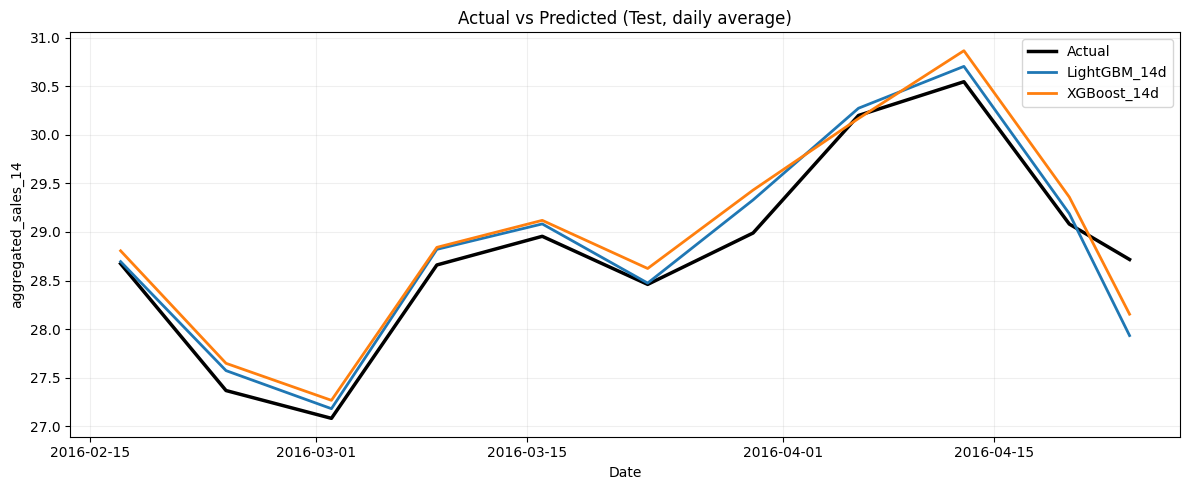

In [9]:
plot_df = X_test[['date']].copy()
plot_df['actual'] = y_test.values
for name, p in preds_test.items():
    plot_df[name] = p

daily = plot_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(daily['date'], daily['actual'], label='Actual', linewidth=2.5, color='black')
plt.plot(daily['date'], daily['LightGBM_14d'], label='LightGBM_14d', linewidth=2)
plt.plot(daily['date'], daily['XGBoost_14d'], label='XGBoost_14d', linewidth=2)
plt.title('Actual vs Predicted (Test, daily average)')
plt.xlabel('Date')
plt.ylabel('aggregated_sales_14')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7) Residual Distributions (Test)
This cell compares error distributions (`prediction - actual`) for both models on the test split.

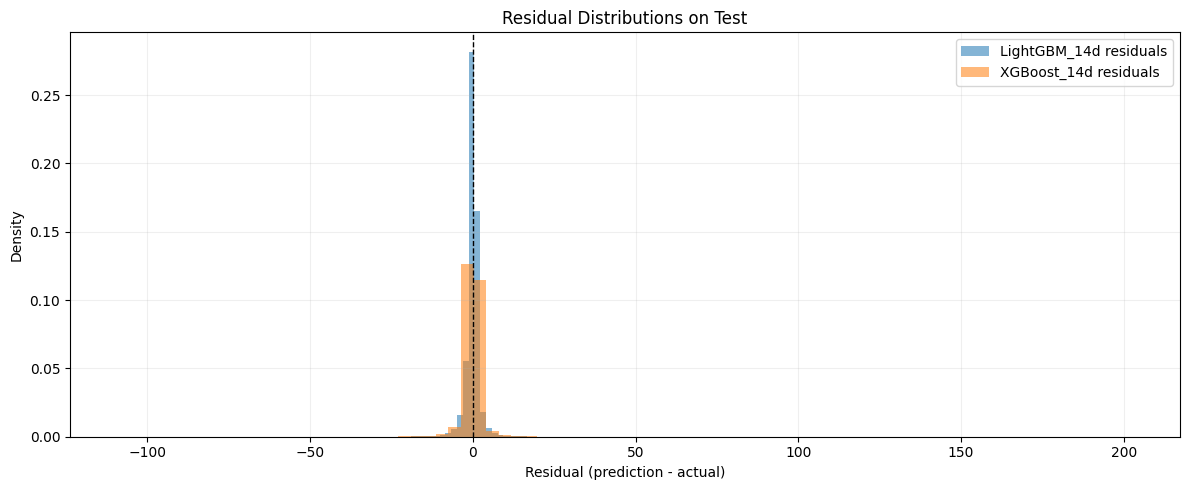

In [10]:
res_lgbm = preds_test['LightGBM_14d'] - y_test.values
res_xgb = preds_test['XGBoost_14d'] - y_test.values

plt.figure(figsize=(12, 5))
plt.hist(res_lgbm, bins=80, alpha=0.55, label='LightGBM_14d residuals', density=True)
plt.hist(res_xgb, bins=80, alpha=0.55, label='XGBoost_14d residuals', density=True)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Distributions on Test')
plt.xlabel('Residual (prediction - actual)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8) Save Comparison Artifacts
This cell saves metrics and test predictions to `artifacts/reports` for tracking and later review.

In [11]:
metrics_path = REPORTS_DIR / 'metrics_lgbm_xgb_14d_comparison.csv'
metrics_df.to_csv(metrics_path, index=False)

preds_out = X_test[['item_id', 'date']].copy()
preds_out['actual'] = y_test.values
preds_out['pred_lgbm_14d'] = preds_test['LightGBM_14d']
preds_out['pred_xgb_14d'] = preds_test['XGBoost_14d']

preds_path = REPORTS_DIR / 'predictions_lgbm_xgb_14d_test.csv'
preds_out.to_csv(preds_path, index=False)

print('Saved metrics to:', metrics_path)
print('Saved predictions to:', preds_path)

Saved metrics to: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_xgb_14d_comparison.csv
Saved predictions to: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\predictions_lgbm_xgb_14d_test.csv
